# Phase 4 — Driver Analysis: What Affects Final 3-Minute Scoring?

Building on P6 snapshot PPM from notebook 03, this notebook analyzes how
specific team characteristics of the **leading** and **trailing** teams
affect endgame scoring rates.

### Drivers
1. **Leading team OREB** — more offensive rebounds = more second-chance possessions
2. **Trailing team 3PT volume** — trailing teams may increase 3PA to close the gap
3. **Trailing team 3PT efficiency** — better shooters make up ground faster
4. **Leading team pace** (sec/poss) — slower teams burn more clock
5. **Trailing team pace** — faster trailing teams create more scoring opportunities

---

## 0 — Setup & Load Data

In [26]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import matplotlib.pyplot as plt
import os, warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

SEASON = 2024
DATA_DIR = os.path.join(os.getcwd(), 'data')

pbp      = pq.read_table(os.path.join(DATA_DIR, f'pbp_{SEASON}.parquet')).to_pandas()
team_box = pq.read_table(os.path.join(DATA_DIR, f'team_box_{SEASON}.parquet')).to_pandas()
schedule = pq.read_table(os.path.join(DATA_DIR, f'schedule_{SEASON}.parquet')).to_pandas()

print(f'PBP: {pbp.shape[0]:,} rows ({pbp["game_id"].nunique():,} games)')
print(f'Team Box: {team_box.shape[0]:,} rows')
print(f'Schedule: {schedule.shape[0]:,} rows')

# ── Fine-grained margin buckets ──
FINE_LABELS = ['0 (Tied)', '1-3', '4-6', '7-9', '10-12', '13-15', '16-18', '19+']

def fine_bucket(m):
    m = int(abs(m))
    if   m == 0:        return '0 (Tied)'
    elif m <= 3:        return '1-3'
    elif m <= 6:        return '4-6'
    elif m <= 9:        return '7-9'
    elif m <= 12:       return '10-12'
    elif m <= 15:       return '13-15'
    elif m <= 18:       return '16-18'
    else:               return '19+'


PBP: 2,004,997 rows (6,151 games)
Team Box: 12,480 rows
Schedule: 6,249 rows


---
## 1 — Power 6 Filter

In [27]:
# ── Conference mapping (reuse from NB03) ──
gmap = schedule[['groups_id', 'groups_short_name']].drop_duplicates().dropna()
gmap['groups_id'] = gmap['groups_id'].astype(int)
conf_id_to_name = gmap.set_index('groups_id')['groups_short_name'].to_dict()

home = schedule[['home_id','home_conference_id']].rename(columns={'home_id':'team_id','home_conference_id':'conf_id'})
away = schedule[['away_id','away_conference_id']].rename(columns={'away_id':'team_id','away_conference_id':'conf_id'})
all_teams = pd.concat([home, away]).dropna(subset=['conf_id'])
all_teams['conf_id'] = all_teams['conf_id'].astype(int)
team_conf = all_teams.groupby('team_id')['conf_id'].agg(lambda x: x.mode().iloc[0]).reset_index()
team_conf['conf'] = team_conf['conf_id'].map(conf_id_to_name)

POWER_6 = ['ACC', 'Big 12', 'Big East', 'Big Ten', 'Pac-12', 'SEC']
p6_ids = set(team_conf[team_conf['conf'].isin(POWER_6)]['team_id'])

p6_games = schedule[
    schedule['home_id'].isin(p6_ids) & schedule['away_id'].isin(p6_ids)
]['game_id'].unique()

pbp_p6 = pbp[pbp['game_id'].isin(p6_games)].copy()
print(f'P6 teams: {len(p6_ids)} | P6-vs-P6 games: {len(p6_games):,}')

P6 teams: 80 | P6-vs-P6 games: 1,041


In [28]:
# ── Regulation data ──
reg = pbp_p6[pbp_p6['period_number'].isin([1, 2])].copy()
reg['home_score'] = pd.to_numeric(reg['home_score'], errors='coerce').fillna(0).astype(int)
reg['away_score'] = pd.to_numeric(reg['away_score'], errors='coerce').fillna(0).astype(int)
reg['score_value'] = pd.to_numeric(reg['score_value'], errors='coerce').fillna(0).astype(int)
reg['secs_remaining'] = pd.to_numeric(reg['end_game_seconds_remaining'], errors='coerce')
reg['margin'] = reg['home_score'] - reg['away_score']
reg = reg.sort_values(['game_id', 'sequence_number']).reset_index(drop=True)

def margin_bucket(m):
    if pd.isna(m): return None
    m = int(m)
    if   m > 15:          return 'Leading >15'
    elif 10 <= m <= 15:   return 'Leading 10-15'
    elif 5  <= m <= 9:    return 'Leading 5-9'
    elif 1  <= m <= 4:    return 'Leading 1-4'
    elif m == 0:          return 'Tied'
    elif -4 <= m <= -1:   return 'Trailing 1-4'
    elif -9 <= m <= -5:   return 'Trailing 5-9'
    elif -15 <= m <= -10: return 'Trailing 10-15'
    else:                 return 'Trailing >15'

BUCKET_ORDER = [
    'Leading >15', 'Leading 10-15', 'Leading 5-9', 'Leading 1-4',
    'Tied',
    'Trailing 1-4', 'Trailing 5-9', 'Trailing 10-15', 'Trailing >15'
]

n_games = reg['game_id'].nunique()
print(f'Regulation: {len(reg):,} events, {n_games:,} games')

Regulation: 335,045 events, 1,041 games


---
## 2 — Team Season Stats & Driver Quartiles

Compute season-level averages from **all games** (full schedule),
then bucket into quartiles.

In [29]:
# ── Compute per-game stats from team_box ──
tb = team_box.copy()
for col in ['offensive_rebounds', 'defensive_rebounds',
            'three_point_field_goals_made', 'three_point_field_goals_attempted',
            'field_goals_attempted', 'turnovers', 'free_throws_attempted',
            'team_score', 'opponent_team_score']:
    tb[col] = pd.to_numeric(tb[col], errors='coerce')

tb['three_pt_pct'] = pd.to_numeric(tb['three_point_field_goal_pct'], errors='coerce')
tb['possessions'] = (tb['field_goals_attempted'] - tb['offensive_rebounds']
                     + tb['turnovers'] + 0.475 * tb['free_throws_attempted'])
tb['sec_per_poss'] = 40 * 60 / tb['possessions']

# Season-level averages per team
team_stats = tb.groupby('team_id').agg(
    avg_oreb=('offensive_rebounds', 'mean'),
    avg_3pa=('three_point_field_goals_attempted', 'mean'),
    avg_3pt_pct=('three_pt_pct', 'mean'),
    avg_sec_per_poss=('sec_per_poss', 'mean'),
    avg_poss=('possessions', 'mean'),
    games=('game_id', 'nunique'),
    team_name=('team_display_name', 'first'),
).reset_index()

# Filter to stable teams
team_stats = team_stats[team_stats['games'] >= 10].copy()

# Assign quartiles for each driver
DRIVERS = {
    'avg_oreb':         ('OREB Q', True),    # higher = more boards = Q1
    'avg_3pa':          ('3PA Q',  True),     # higher volume = Q1
    'avg_3pt_pct':      ('3P% Q',  True),     # higher pct = Q1
    'avg_sec_per_poss': ('Pace Q', False),    # LOWER sec/poss = faster = Q1
}

for col, (q_name, ascending_is_q1) in DRIVERS.items():
    if ascending_is_q1:
        # Higher value = Q1 (best), so we reverse the labels
        team_stats[q_name] = pd.qcut(
            team_stats[col], q=4,
            labels=['Q4 (Low)', 'Q3', 'Q2', 'Q1 (High)']
        )
    else:
        # Lower value = Q1 (fastest)
        team_stats[q_name] = pd.qcut(
            team_stats[col], q=4,
            labels=['Q1 (Fast)', 'Q2', 'Q3', 'Q4 (Slow)']
        )

print(f'Teams with season stats: {len(team_stats)}')
print(f'\n=== Driver Distributions ===')
for col, (q_name, _) in DRIVERS.items():
    print(f'\n{q_name} ({col}):')
    desc = team_stats.groupby(q_name)[col].agg(['count', 'mean', 'min', 'max']).round(2)
    print(desc.to_string())

Teams with season stats: 362

=== Driver Distributions ===

OREB Q (avg_oreb):
           count   mean    min    max
OREB Q                               
Q4 (Low)      92   8.16   5.70   9.16
Q3            89   9.70   9.16  10.12
Q2            90  10.75  10.15  11.39
Q1 (High)     91  12.48  11.39  17.42

3PA Q (avg_3pa):
           count   mean    min    max
3PA Q                                
Q4 (Low)      91  17.92  13.88  19.74
Q3            90  20.85  19.78  21.88
Q2            91  22.95  21.92  23.94
Q1 (High)     90  26.07  23.97  33.22

3P% Q (avg_3pt_pct):
           count   mean    min    max
3P% Q                                
Q4 (Low)      91  30.61  24.85  32.23
Q3            90  33.10  32.24  33.94
Q2            90  34.71  33.97  35.53
Q1 (High)     91  36.68  35.53  40.32

Pace Q (avg_sec_per_poss):
           count   mean    min    max
Pace Q                               
Q1 (Fast)     91  33.27  31.69  34.04
Q2            90  34.48  34.07  34.85
Q3            90 

In [30]:
# ── Show P6 teams' driver stats ──
p6_stats = team_stats[team_stats['team_id'].isin(p6_ids)].copy()
print(f'P6 teams with stats: {len(p6_stats)}')

print(f'\n=== P6 Team Driver Averages ===')
for col in ['avg_oreb', 'avg_3pa', 'avg_3pt_pct', 'avg_sec_per_poss']:
    print(f'  {col:<20} mean={p6_stats[col].mean():.2f}  min={p6_stats[col].min():.2f}  max={p6_stats[col].max():.2f}')

P6 teams with stats: 80

=== P6 Team Driver Averages ===
  avg_oreb             mean=10.51  min=7.28  max=17.42
  avg_3pa              mean=22.15  min=15.55  max=31.97
  avg_3pt_pct          mean=34.43  min=27.94  max=40.32
  avg_sec_per_poss     mean=34.83  min=32.36  max=39.17


---
## 3 — Identify Leading & Trailing Teams at 3:00 Mark

In [31]:
# ── Snapshot margin at 180s and assign leading/trailing team IDs ──
def get_entry_info(reg_df, window_secs):
    pre = reg_df[reg_df['secs_remaining'] >= window_secs]
    entry = pre.groupby('game_id').last()
    return entry[['margin', 'home_team_id', 'away_team_id', 'home_score', 'away_score']]

entry_3 = get_entry_info(reg, 180)
entry_3['margin_bucket'] = entry_3['margin'].apply(margin_bucket)
entry_3['fine_bucket'] = entry_3['margin'].apply(fine_bucket)

# Leading = home if margin > 0, away if margin < 0
entry_3['leading_team_id'] = np.where(
    entry_3['margin'] > 0, entry_3['home_team_id'],
    np.where(entry_3['margin'] < 0, entry_3['away_team_id'], np.nan)
)
entry_3['trailing_team_id'] = np.where(
    entry_3['margin'] > 0, entry_3['away_team_id'],
    np.where(entry_3['margin'] < 0, entry_3['home_team_id'], np.nan)
)

# Drop ties (no leading/trailing in ties)
entry_3_lt = entry_3[entry_3['margin'] != 0].copy()
entry_3_lt['abs_margin'] = entry_3_lt['margin'].abs()
entry_3_lt['fine_bucket'] = entry_3_lt['margin'].apply(fine_bucket)

print(f'Total games at 3:00 mark: {len(entry_3):,}')
print(f'  With leader/trailer:    {len(entry_3_lt):,}')
print(f'  Tied (excluded):        {(entry_3["margin"]==0).sum():,}')
print(f'\n=== Margin Bucket Distribution ===')
for b in BUCKET_ORDER:
    cnt = (entry_3['margin_bucket'] == b).sum()
    print(f'  {b:<20} {cnt:>5}')

Total games at 3:00 mark: 1,041
  With leader/trailer:    943
  Tied (excluded):        98

=== Margin Bucket Distribution ===
  Leading >15            192
  Leading 10-15          159
  Leading 5-9            117
  Leading 1-4            129
  Tied                    98
  Trailing 1-4            86
  Trailing 5-9           104
  Trailing 10-15          80
  Trailing >15            76


---
## 4 — Merge Driver Quartiles into Game Data

In [32]:
# ── Build lookup dicts for each driver quartile ──
driver_lookups = {}
for col, (q_name, _) in DRIVERS.items():
    driver_lookups[q_name] = team_stats.set_index('team_id')[q_name].to_dict()

# ── Map driver quartiles for leading and trailing teams ──
for q_name, lookup in driver_lookups.items():
    entry_3_lt[f'lead_{q_name}'] = entry_3_lt['leading_team_id'].map(lookup)
    entry_3_lt[f'trail_{q_name}'] = entry_3_lt['trailing_team_id'].map(lookup)

# Show coverage
for q_name in driver_lookups:
    lead_cov = entry_3_lt[f'lead_{q_name}'].notna().mean()
    trail_cov = entry_3_lt[f'trail_{q_name}'].notna().mean()
    print(f'{q_name}: lead coverage={lead_cov:.1%}, trail coverage={trail_cov:.1%}')

OREB Q: lead coverage=100.0%, trail coverage=100.0%
3PA Q: lead coverage=100.0%, trail coverage=100.0%
3P% Q: lead coverage=100.0%, trail coverage=100.0%
Pace Q: lead coverage=100.0%, trail coverage=100.0%


---
## 5 — PPM by Driver Quartile (Final 3 Minutes)

For each driver, compute total PPM in the final 3 minutes,
bucketed by the leading or trailing team's quartile for that stat.

In [33]:
# ── Get all F3 scoring events ──
scoring_3 = reg[(reg['scoring_play'] == True) & (reg['secs_remaining'] <= 180)].copy()
scoring_3['entry_bucket'] = scoring_3['game_id'].map(entry_3['fine_bucket'])
scoring_3 = scoring_3.dropna(subset=['entry_bucket'])

# Only non-tied games
scoring_3_lt = scoring_3[scoring_3['game_id'].isin(entry_3_lt.index)].copy()

# Merge driver quartiles into scoring events
for q_name in driver_lookups:
    scoring_3_lt[f'lead_{q_name}'] = scoring_3_lt['game_id'].map(
        entry_3_lt[f'lead_{q_name}'])
    scoring_3_lt[f'trail_{q_name}'] = scoring_3_lt['game_id'].map(
        entry_3_lt[f'trail_{q_name}'])

print(f'F3 scoring events (non-tied): {len(scoring_3_lt):,}')
print(f'Games: {scoring_3_lt["game_id"].nunique():,}')

F3 scoring events (non-tied): 9,237
Games: 942


In [34]:
# ── PPM computation by driver quartile ──
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#e0e0e0', 'ytick.color': '#e0e0e0',
    'font.size': 11, 'axes.titlesize': 14, 'figure.titlesize': 16,
})

DRIVER_CONFIGS = [
    ('lead_OREB Q',  'Leading Team OREB',  ['Q1 (High)','Q2','Q3','Q4 (Low)']),
    ('trail_3PA Q',  'Trailing Team 3PA Volume', ['Q1 (High)','Q2','Q3','Q4 (Low)']),
    ('trail_3P% Q',  'Trailing Team 3P%',  ['Q1 (High)','Q2','Q3','Q4 (Low)']),
    ('lead_Pace Q',  'Leading Team Pace',  ['Q1 (Fast)','Q2','Q3','Q4 (Slow)']),
    ('trail_Pace Q', 'Trailing Team Pace', ['Q1 (Fast)','Q2','Q3','Q4 (Slow)']),
]

all_driver_results = []

for driver_col, driver_label, q_labels in DRIVER_CONFIGS:
    s_valid = scoring_3_lt.dropna(subset=[driver_col])
    games_valid = entry_3_lt.dropna(subset=[driver_col])
    
    pts_by_q = s_valid.groupby(driver_col)['score_value'].sum()
    games_by_q = games_valid[driver_col].value_counts()
    
    rows = []
    for q in q_labels:
        pts = pts_by_q.get(q, 0)
        n_g = games_by_q.get(q, 0)
        ppm = pts / (n_g * 3) if n_g > 0 else 0
        rows.append({'Driver': driver_label, 'Quartile': q, 'Games': n_g,
                     'Total Pts': int(pts), 'PPM': round(ppm, 3)})
    all_driver_results.extend(rows)

driver_df = pd.DataFrame(all_driver_results)

print('=== PPM by Driver Quartile — Final 3 Minutes (P6, non-tied) ===')
for driver_label in driver_df['Driver'].unique():
    print(f'\n--- {driver_label} ---')
    sub = driver_df[driver_df['Driver'] == driver_label][['Quartile','Games','Total Pts','PPM']]
    display(sub.reset_index(drop=True))

=== PPM by Driver Quartile — Final 3 Minutes (P6, non-tied) ===

--- Leading Team OREB ---


,Quartile,Games,Total Pts,PPM
0,Q1 (High),336,5191,5.150
1,Q2,154,2339,5.063
2,Q3,269,4020,4.981
3,Q4 (Low),184,2858,5.178



--- Trailing Team 3PA Volume ---


,Quartile,Games,Total Pts,PPM
0,Q1 (High),186,2810,5.036
1,Q2,313,5008,5.333
2,Q3,221,3368,5.080
3,Q4 (Low),223,3222,4.816



--- Trailing Team 3P% ---


,Quartile,Games,Total Pts,PPM
0,Q1 (High),273,4230,5.165
1,Q2,237,3657,5.143
2,Q3,246,3602,4.881
3,Q4 (Low),187,2919,5.203



--- Leading Team Pace ---


,Quartile,Games,Total Pts,PPM
0,Q1 (Fast),235,3782,5.365
1,Q2,234,3661,5.215
2,Q3,260,3975,5.096
3,Q4 (Slow),214,2990,4.657



--- Trailing Team Pace ---


,Quartile,Games,Total Pts,PPM
0,Q1 (Fast),208,3288,5.269
1,Q2,264,3953,4.991
2,Q3,304,4620,5.066
3,Q4 (Slow),167,2547,5.084


---
## 6 — Visualizations

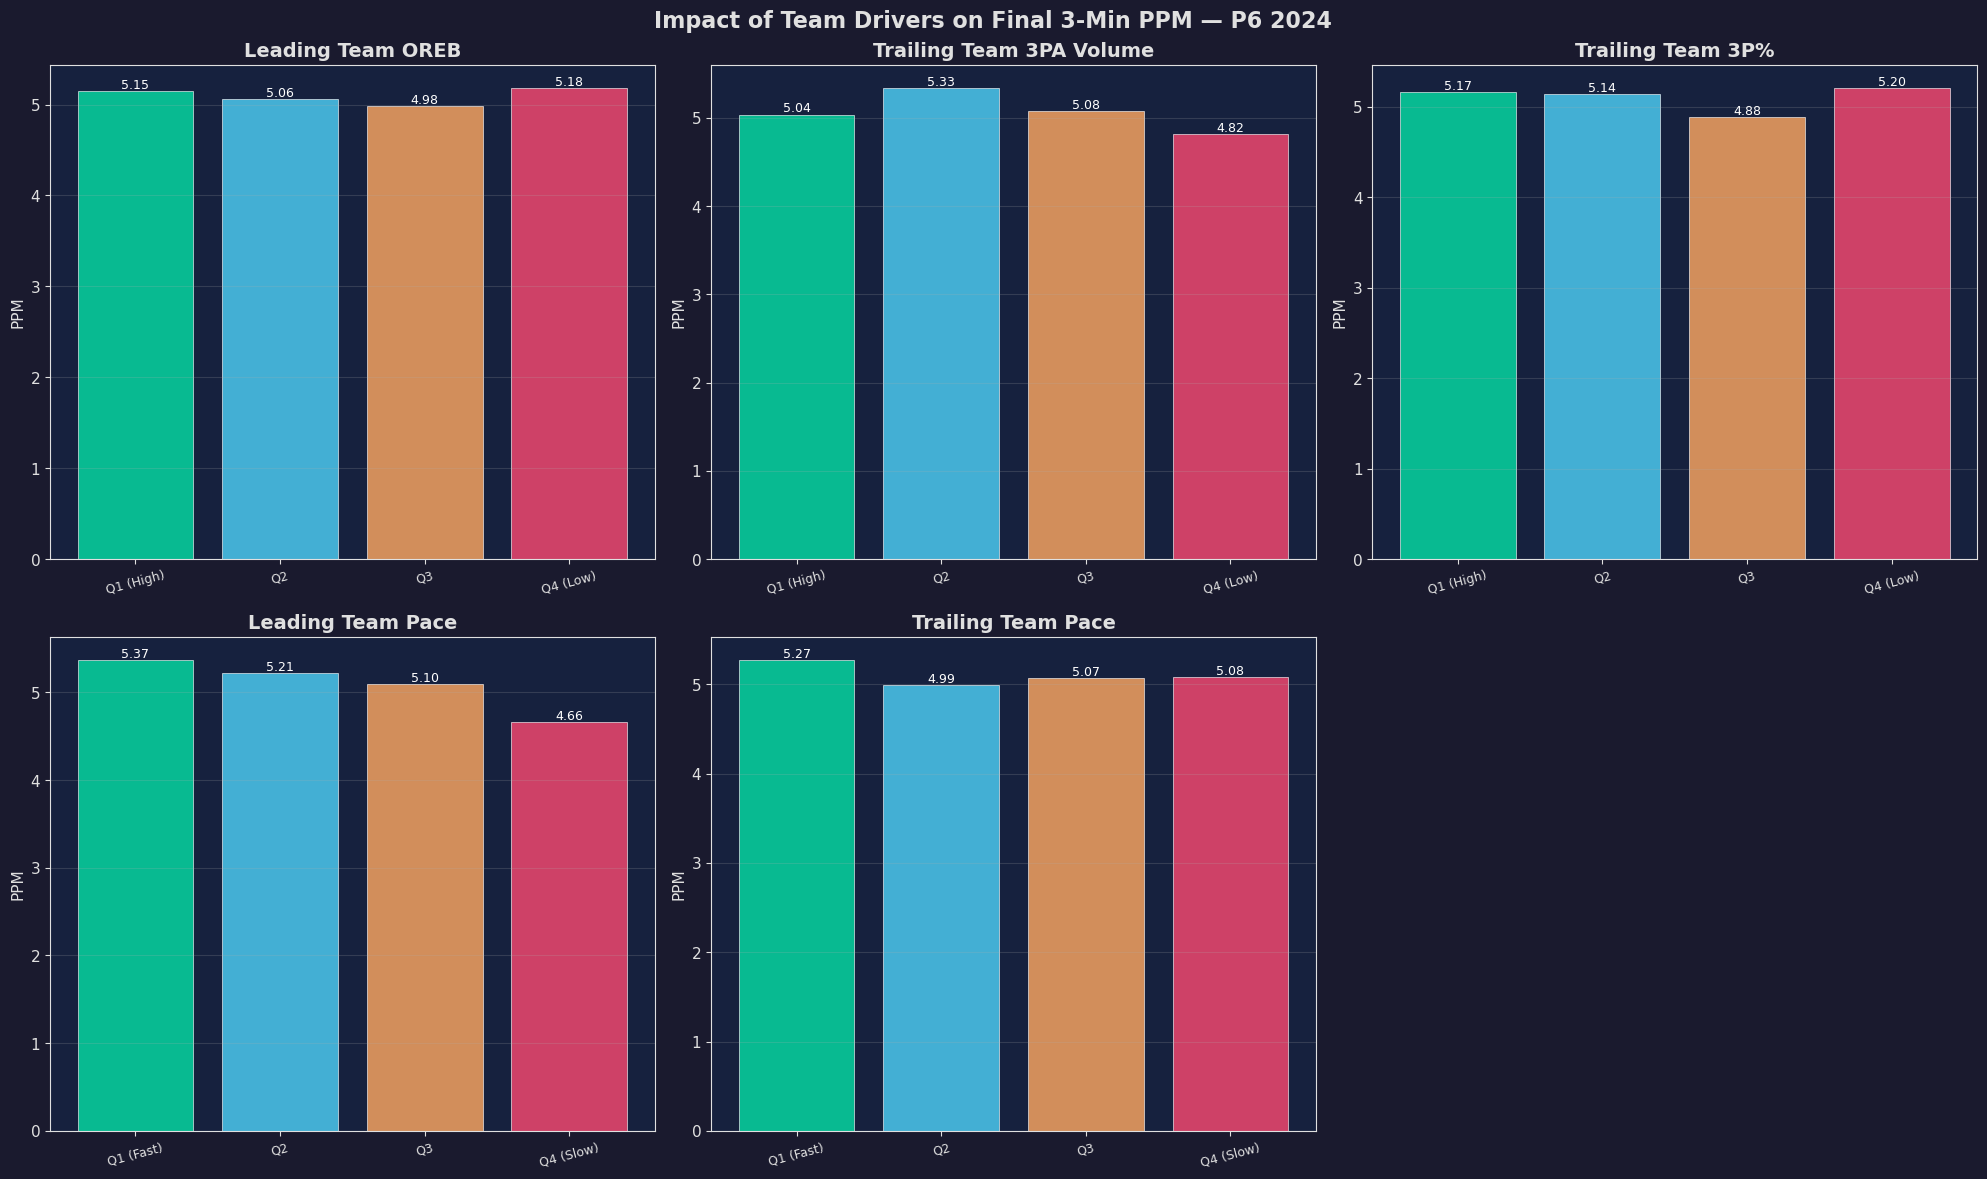

Saved: viz_driver_ppm.png


In [35]:
# ── VIZ 1: PPM by each driver (grouped bar) ──
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'Impact of Team Drivers on Final 3-Min PPM — P6 {SEASON}',
             fontsize=16, fontweight='bold')

driver_colors = ['#06d6a0', '#4cc9f0', '#f4a261', '#ef476f']

for idx, (driver_col, driver_label, q_labels) in enumerate(DRIVER_CONFIGS):
    ax = axes.flat[idx]
    sub = driver_df[driver_df['Driver'] == driver_label]
    ppms = [sub[sub['Quartile'] == q]['PPM'].values[0] for q in q_labels]
    
    bars = ax.bar(range(len(q_labels)), ppms, color=driver_colors, alpha=0.85,
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(q_labels)))
    ax.set_xticklabels(q_labels, fontsize=9, rotation=15)
    ax.set_ylabel('PPM')
    ax.set_title(driver_label, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    
    for i, v in enumerate(ppms):
        ax.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=9, color='white')

# Hide unused subplot
axes.flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'viz_driver_ppm.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_driver_ppm.png')

---
## 7 — Driver × Margin Bucket Profiles

Each of the 5 drivers **individually paired** with **all** point differential buckets.
PPM = total_pts / (games_in_cell × 3 minutes).

In [36]:
# ── PPM by driver quartile x ALL margin buckets for ALL 5 drivers ──
interaction_results = []

for driver_col, driver_label, q_labels in DRIVER_CONFIGS:
    s_valid = scoring_3_lt.dropna(subset=[driver_col])
    games_valid = entry_3_lt.dropna(subset=[driver_col])
    
    for b in FINE_LABELS:
        s_bucket = s_valid[s_valid['entry_bucket'] == b]
        g_bucket = games_valid[games_valid['fine_bucket'] == b]
        
        for q in q_labels:
            pts = s_bucket[s_bucket[driver_col] == q]['score_value'].sum()
            n_g = (g_bucket[driver_col] == q).sum()
            ppm = pts / (n_g * 3) if n_g > 0 else np.nan
            interaction_results.append({
                'Driver': driver_label, 'Quartile': q,
                'Margin Bucket': b, 'Games': n_g,
                'Total Pts': int(pts),
                'PPM': round(ppm, 3) if not np.isnan(ppm) else np.nan
            })

inter_df = pd.DataFrame(interaction_results)
print(f'Total profiles computed: {len(inter_df)} (5 drivers × {len(FINE_LABELS)} buckets × 4 quartiles)')

Total profiles computed: 160 (5 drivers × 8 buckets × 4 quartiles)


In [37]:
# ── TABLE: Driver 1 — Leading Team OREB × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Leading Team OREB']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(FINE_LABELS)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(FINE_LABELS)

print('=== 1. Leading Team OREB × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 1. Leading Team OREB × Margin Bucket PPM ===
PPM:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,NaN
1-3,5.245,5.074,5.072,5.188
4-6,5.527,5.333,5.034,5.705
7-9,6.027,6.017,5.260,6.107
10-12,5.719,4.685,6.123,5.333
13-15,5.010,5.088,4.883,6.019
16-18,4.713,5.178,4.413,4.400
19+,4.217,4.274,3.877,3.982



Games per cell:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
0 (Tied),0,0,0,0
1-3,49,27,60,32
4-6,50,27,39,26
7-9,49,20,32,25
10-12,45,18,38,30
13-15,34,19,37,18
16-18,29,15,25,15
19+,80,28,38,38


In [38]:
# ── TABLE: Driver 2 — Trailing Team 3PA Volume × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Trailing Team 3PA Volume']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(FINE_LABELS)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(FINE_LABELS)

print('=== 2. Trailing Team 3PA Volume × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 2. Trailing Team 3PA Volume × Margin Bucket PPM ===
PPM:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,NaN
1-3,5.108,5.464,4.851,5.008
4-6,5.101,5.537,5.307,5.621
7-9,5.840,6.008,5.778,5.679
10-12,5.381,5.667,5.521,5.769
13-15,5.333,5.342,5.049,4.806
16-18,4.978,4.859,4.333,4.472
19+,4.061,4.333,4.431,3.765



Games per cell:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
0 (Tied),0,0,0,0
1-3,34,56,38,40
4-6,33,49,38,22
7-9,25,42,33,26
10-12,21,52,32,26
13-15,20,37,27,24
16-18,15,26,19,24
19+,38,51,34,61


In [39]:
# ── TABLE: Driver 3 — Trailing Team 3P% × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Trailing Team 3P%']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(FINE_LABELS)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(FINE_LABELS)

print('=== 3. Trailing Team 3P% × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 3. Trailing Team 3P% × Margin Bucket PPM ===
PPM:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,NaN
1-3,5.091,5.457,5.035,5.063
4-6,5.185,5.352,5.705,5.538
7-9,5.667,5.843,5.967,5.949
10-12,5.360,5.128,5.926,6.286
13-15,5.856,4.925,4.847,4.841
16-18,4.613,5.000,4.088,4.889
19+,4.421,4.325,3.688,4.238



Games per cell:


Quartile,Q1 (High),Q2,Q3,Q4 (Low)
Margin Bucket,,,,
0 (Tied),0,0,0,0
1-3,55,35,57,21
4-6,54,36,26,26
7-9,34,36,30,26
10-12,37,39,27,28
13-15,30,31,24,23
16-18,25,19,19,21
19+,38,41,63,42


In [40]:
# ── TABLE: Driver 4 — Leading Team Pace × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Leading Team Pace']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(FINE_LABELS)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(FINE_LABELS)

print('=== 4. Leading Team Pace × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 4. Leading Team Pace × Margin Bucket PPM ===
PPM:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,NaN
1-3,5.530,5.171,5.067,4.788
4-6,5.550,5.533,5.163,5.353
7-9,6.083,6.162,5.970,4.987
10-12,5.550,6.571,5.460,4.689
13-15,5.813,4.430,5.356,5.130
16-18,4.810,4.650,4.819,4.263
19+,4.654,4.061,3.754,3.847



Games per cell:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
0 (Tied),0,0,0,0
1-3,39,41,55,33
4-6,37,30,41,34
7-9,24,33,44,25
10-12,37,35,29,30
13-15,25,31,29,23
16-18,21,20,24,19
19+,52,44,38,50


In [41]:
# ── TABLE: Driver 5 — Trailing Team Pace × Margin Bucket ──
d = inter_df[inter_df['Driver'] == 'Trailing Team Pace']
pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                      sort=False).reindex(FINE_LABELS)
games_pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='Games',
                            aggfunc='sum', sort=False).reindex(FINE_LABELS)

print('=== 5. Trailing Team Pace × Margin Bucket PPM ===')
print('PPM:')
display(pivot)
print('\nGames per cell:')
display(games_pivot)

=== 5. Trailing Team Pace × Margin Bucket PPM ===
PPM:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,NaN
1-3,5.517,5.167,4.947,4.900
4-6,5.571,4.757,5.442,5.892
7-9,5.233,5.726,6.903,5.474
10-12,5.611,6.079,5.205,5.587
13-15,5.403,4.742,5.042,5.714
16-18,5.290,4.514,4.377,4.286
19+,4.521,3.913,4.211,3.605



Games per cell:


Quartile,Q1 (Fast),Q2,Q3,Q4 (Slow)
Margin Bucket,,,,
0 (Tied),0,0,0,0
1-3,40,54,44,30
4-6,28,37,46,31
7-9,30,39,31,26
10-12,24,38,44,25
13-15,24,22,48,14
16-18,23,24,23,14
19+,39,50,68,27


---
## 8a — Validate Point-Differential Bucketing

Before assessing drivers, confirm the distribution of absolute margins at
the **3-minute** and **5-minute** snapshots looks reasonable.

Buckets: `0 (Tied)`, `1-3`, `4-6`, `7-9`, `10-12`, `13-15`, `16-18`, `19+`

=== Margin Distribution at 3-Minute Snapshot ===
  0 (Tied)       98
  1-3           168
  4-6           142
  7-9           126
  10-12         131
  13-15         108
  16-18          84
  19+           184
  TOTAL        1041

=== Margin Distribution at 5-Minute Snapshot ===
  0 (Tied)       44
  1-3           182
  4-6           180
  7-9           139
  10-12         137
  13-15         112
  16-18          81
  19+           166
  TOTAL        1041


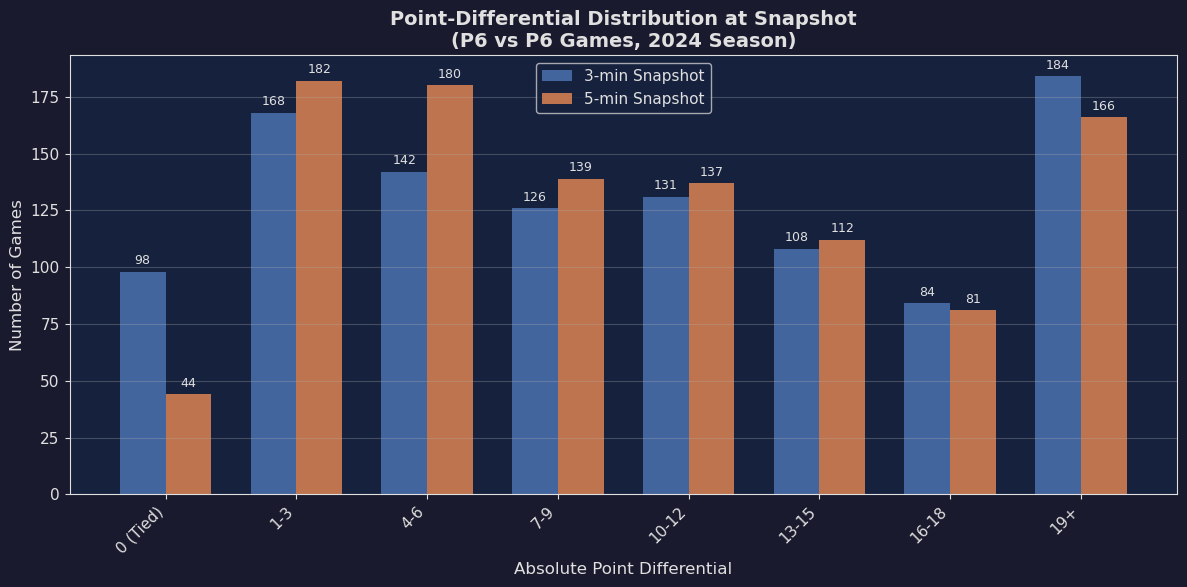

Saved: data/viz_margin_distribution.png


In [42]:
# ── 5-Minute Snapshot (if not already built) ──
entry_5 = get_entry_info(reg, 300)
entry_5['margin_bucket'] = entry_5['margin'].apply(margin_bucket)
entry_5['abs_margin'] = entry_5['margin'].abs()

entry_3['abs_margin'] = entry_3['margin'].abs()  # add to 3-min too

# fine_bucket() and FINE_LABELS are defined in the setup cell above

entry_3['fine_bucket'] = entry_3['margin'].apply(fine_bucket)
entry_5['fine_bucket'] = entry_5['margin'].apply(fine_bucket)

counts_3 = entry_3['fine_bucket'].value_counts().reindex(FINE_LABELS, fill_value=0)
counts_5 = entry_5['fine_bucket'].value_counts().reindex(FINE_LABELS, fill_value=0)

print('=== Margin Distribution at 3-Minute Snapshot ===')
for b, c in counts_3.items():
    print(f'  {b:10s}  {c:>5}')
print(f'  {"TOTAL":10s}  {counts_3.sum():>5}')

print('\n=== Margin Distribution at 5-Minute Snapshot ===')
for b, c in counts_5.items():
    print(f'  {b:10s}  {c:>5}')
print(f'  {"TOTAL":10s}  {counts_5.sum():>5}')

# ── Grouped Bar Chart ──
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(FINE_LABELS))
width = 0.35

bars_3 = ax.bar(x - width/2, counts_3.values, width,
                label='3-min Snapshot', color='#4C72B0', alpha=0.85)
bars_5 = ax.bar(x + width/2, counts_5.values, width,
                label='5-min Snapshot', color='#DD8452', alpha=0.85)

ax.set_xlabel('Absolute Point Differential', fontsize=12)
ax.set_ylabel('Number of Games', fontsize=12)
ax.set_title('Point-Differential Distribution at Snapshot\n'
             '(P6 vs P6 Games, 2024 Season)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(FINE_LABELS, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate counts above bars
for bar in bars_3:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 2,
                str(int(h)), ha='center', va='bottom', fontsize=9)
for bar in bars_5:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 2,
                str(int(h)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/viz_margin_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/viz_margin_distribution.png')

---
## 7b — Heatmap Visualizations (All Drivers × All Buckets)

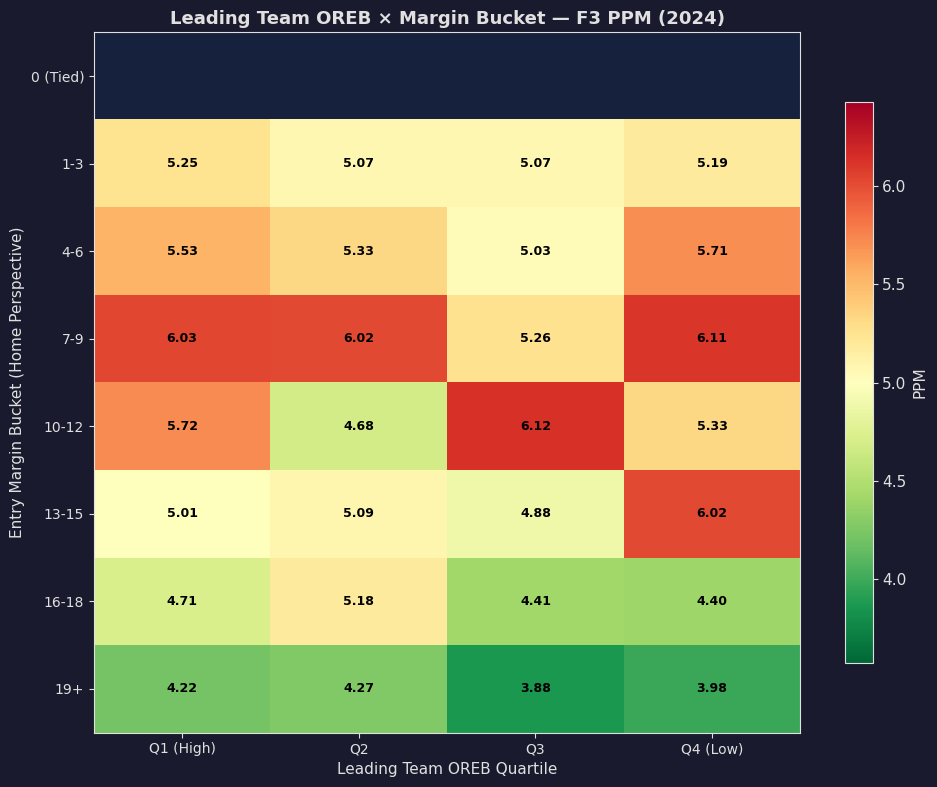

Saved: viz_driver_lead_oreb_q_heatmap.png


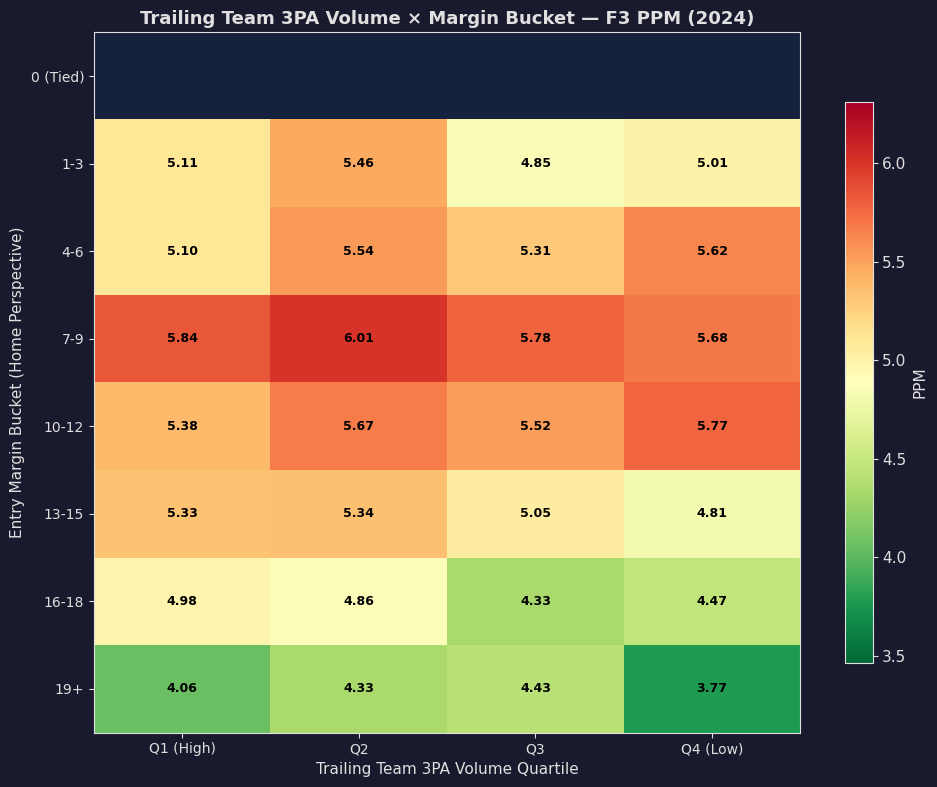

Saved: viz_driver_trail_3pa_q_heatmap.png


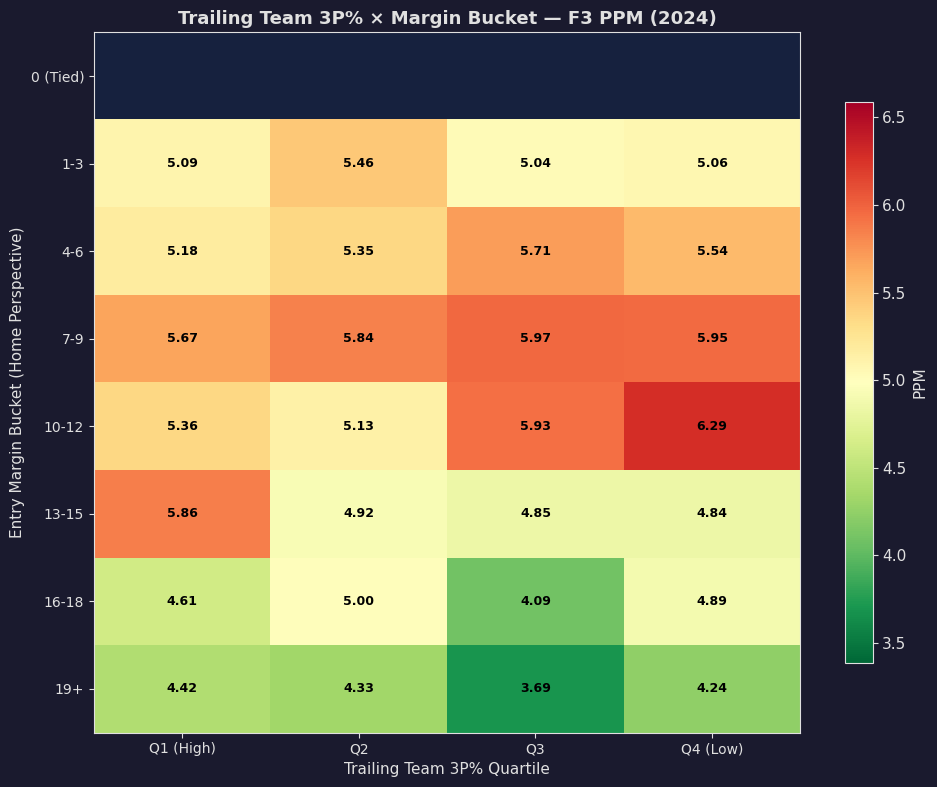

Saved: viz_driver_trail_3p%_q_heatmap.png


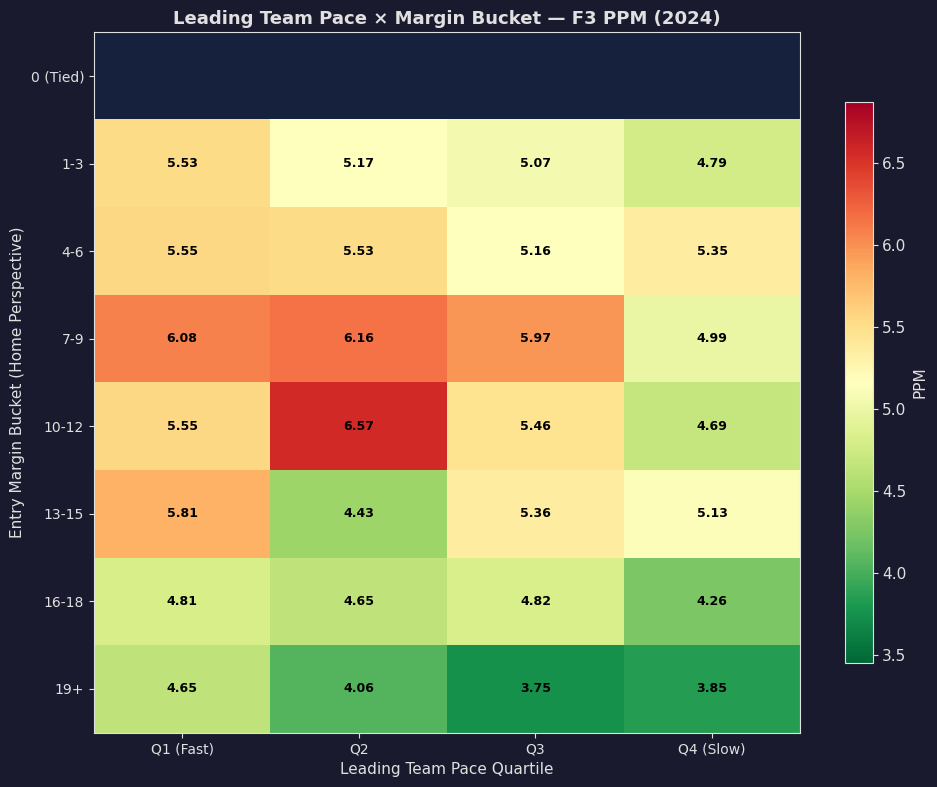

Saved: viz_driver_lead_pace_q_heatmap.png


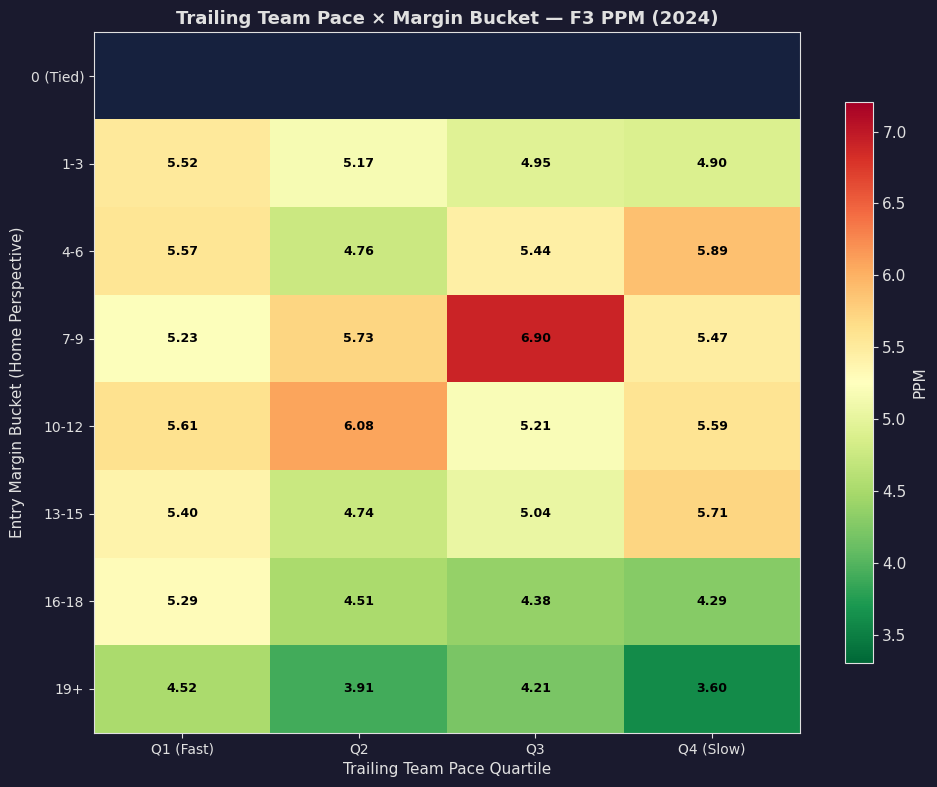

Saved: viz_driver_trail_pace_q_heatmap.png


In [43]:
# ── VIZ: Individual heatmap per driver (5 plots) ──
for driver_col, driver_label, q_labels in DRIVER_CONFIGS:
    fig, ax = plt.subplots(figsize=(10, 8))
    d = inter_df[inter_df['Driver'] == driver_label]
    pivot = d.pivot_table(index='Margin Bucket', columns='Quartile', values='PPM',
                          sort=False).reindex(FINE_LABELS)[q_labels]
    
    valid_vals = pivot.values[~np.isnan(pivot.values)]
    if len(valid_vals) == 0:
        continue
    
    im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
                   vmin=valid_vals.min() - 0.3,
                   vmax=valid_vals.max() + 0.3)
    ax.set_xticks(range(len(q_labels)))
    ax.set_xticklabels(q_labels, fontsize=10)
    ax.set_yticks(range(len(FINE_LABELS)))
    ax.set_yticklabels(FINE_LABELS, fontsize=10)
    ax.set_xlabel(driver_label + ' Quartile')
    ax.set_ylabel('Entry Margin Bucket (Home Perspective)')
    ax.set_title(f'{driver_label} × Margin Bucket — F3 PPM ({SEASON})',
                 fontweight='bold', fontsize=13)
    
    for i in range(len(FINE_LABELS)):
        for j in range(len(q_labels)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=9, color='black', fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='PPM', shrink=0.8)
    plt.tight_layout()
    fname = f'viz_driver_{driver_col.replace(" ", "_").lower()}_heatmap.png'
    plt.savefig(os.path.join(DATA_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

---
## 8 — Combined Driver Effects

Look at games where multiple drivers align (e.g., trailing team with
high 3PA volume AND high 3P%, or leading team with high OREB AND slow pace).

In [44]:
# ── Combined: trailing team 3PA Q1 + 3P% Q1 vs Q4 + Q4 ──
g = entry_3_lt.copy()

# Good trailing shooters: high volume + high efficiency
g['trail_good_shooter'] = (
    (g['trail_3PA Q'] == 'Q1 (High)') & (g['trail_3P% Q'] == 'Q1 (High)')
)
g['trail_poor_shooter'] = (
    (g['trail_3PA Q'] == 'Q4 (Low)') & (g['trail_3P% Q'] == 'Q4 (Low)')
)

# Stalling leaders: high OREB + slow pace
g['lead_stall'] = (
    (g['lead_OREB Q'] == 'Q1 (High)') & (g['lead_Pace Q'] == 'Q4 (Slow)')
)
g['lead_fast_no_boards'] = (
    (g['lead_OREB Q'] == 'Q4 (Low)') & (g['lead_Pace Q'] == 'Q1 (Fast)')
)

combos = {
    'Trail: High 3PA + High 3P%': 'trail_good_shooter',
    'Trail: Low 3PA + Low 3P%':   'trail_poor_shooter',
    'Lead: High OREB + Slow Pace': 'lead_stall',
    'Lead: Low OREB + Fast Pace':  'lead_fast_no_boards',
}

combo_rows = []
for label, col in combos.items():
    game_ids = g[g[col]].index
    n_g = len(game_ids)
    pts = scoring_3_lt[scoring_3_lt['game_id'].isin(game_ids)]['score_value'].sum()
    ppm = pts / (n_g * 3) if n_g > 0 else 0
    combo_rows.append({'Profile': label, 'Games': n_g, 'Total Pts': int(pts),
                       'PPM': round(ppm, 3)})

combo_df = pd.DataFrame(combo_rows)

# Baseline: all non-tied games
baseline_pts = scoring_3_lt['score_value'].sum()
baseline_games = len(entry_3_lt)
baseline_ppm = baseline_pts / (baseline_games * 3)
print(f'Baseline PPM (all non-tied F3): {baseline_ppm:.3f}')

print(f'\n=== Combined Driver Profiles — Final 3 Min PPM ===')
display(combo_df)

Baseline PPM (all non-tied F3): 5.093

=== Combined Driver Profiles — Final 3 Min PPM ===


,Profile,Games,Total Pts,PPM
0,Trail: High 3PA + High 3P%,96,1428,4.958
1,Trail: Low 3PA + Low 3P%,79,1155,4.873
2,Lead: High OREB + Slow Pace,68,938,4.598
3,Lead: Low OREB + Fast Pace,26,472,6.051


---
## 8b — Team Profile: Slow Pace + Low 3P% + Low OREB

Filter to games matching **all four** conditions:

| Driver | Allowed Quartiles |
|---|---|
| Trailing team pace | Q2, Q3, or Q4 (not Q1 Fast) |
| Leading team pace | Q2, Q3, or Q4 (not Q1 Fast) |
| Trailing team 3P% | Q3 or Q4 (Low) |
| Leading team OREB | Q3 or Q4 (Low) |

Then compute PPM by margin bucket at both the **3-minute** and **5-minute** snapshots.

In [45]:
# ── 5-Minute Snapshot (same pattern as the 3-min snapshot) ──
entry_5 = get_entry_info(reg, 300)
entry_5['margin_bucket'] = entry_5['margin'].apply(margin_bucket)
entry_5['fine_bucket'] = entry_5['margin'].apply(fine_bucket)

entry_5['leading_team_id'] = np.where(
    entry_5['margin'] > 0, entry_5['home_team_id'],
    np.where(entry_5['margin'] < 0, entry_5['away_team_id'], np.nan)
)
entry_5['trailing_team_id'] = np.where(
    entry_5['margin'] > 0, entry_5['away_team_id'],
    np.where(entry_5['margin'] < 0, entry_5['home_team_id'], np.nan)
)

entry_5_lt = entry_5[entry_5['margin'] != 0].copy()
entry_5_lt['abs_margin'] = entry_5_lt['margin'].abs()
entry_5_lt['fine_bucket'] = entry_5_lt['margin'].apply(fine_bucket)

# Map driver quartiles onto the 5-min snapshot
for q_name, lookup in driver_lookups.items():
    entry_5_lt[f'lead_{q_name}'] = entry_5_lt['leading_team_id'].map(lookup)
    entry_5_lt[f'trail_{q_name}'] = entry_5_lt['trailing_team_id'].map(lookup)

# 5-min scoring events
scoring_5 = reg[(reg['scoring_play'] == True) & (reg['secs_remaining'] <= 300)].copy()
scoring_5['entry_bucket'] = scoring_5['game_id'].map(entry_5['fine_bucket'])
scoring_5 = scoring_5.dropna(subset=['entry_bucket'])
scoring_5_lt = scoring_5[scoring_5['game_id'].isin(entry_5_lt.index)].copy()

print(f'5-min snapshot: {len(entry_5_lt):,} non-tied games, '
      f'{len(scoring_5_lt):,} scoring events')

# ── Team Profile Filter ──
def apply_profile_mask(df):
    return (
        (df['trail_Pace Q'].isin(['Q2', 'Q3', 'Q4 (Slow)'])) &
        (df['lead_Pace Q'].isin(['Q2', 'Q3', 'Q4 (Slow)'])) &
        (df['trail_3P% Q'].isin(['Q3', 'Q4 (Low)'])) &
        (df['lead_OREB Q'].isin(['Q3', 'Q4 (Low)']))
    )

profile_3_games = set(entry_3_lt[apply_profile_mask(entry_3_lt)].index)
profile_5_games = set(entry_5_lt[apply_profile_mask(entry_5_lt)].index)

print(f'Profile matches — 3-min: {len(profile_3_games)} games, '
      f'5-min: {len(profile_5_games)} games')

# ── PPM by Margin Bucket ──
def compute_profile_ppm(profile_ids, scoring_df, window_mins, snapshot_entry):
    rows = []
    for bucket in FINE_LABELS:
        bucket_ids = [g for g in profile_ids
                      if snapshot_entry.loc[g, 'fine_bucket'] == bucket]
        n_g = len(bucket_ids)
        if n_g == 0:
            rows.append({'Margin Bucket': bucket, 'Games': 0,
                         'Total Pts': 0, 'PPM': np.nan})
            continue
        pts = scoring_df[scoring_df['game_id'].isin(bucket_ids)]['score_value'].sum()
        ppm = pts / (n_g * window_mins)
        rows.append({'Margin Bucket': bucket, 'Games': n_g,
                     'Total Pts': int(pts), 'PPM': round(ppm, 3)})
    return pd.DataFrame(rows)

ppm_3 = compute_profile_ppm(profile_3_games, scoring_3_lt, 3, entry_3_lt)
ppm_5 = compute_profile_ppm(profile_5_games, scoring_5_lt, 5, entry_5_lt)

# Baselines
baseline_3_ppm = scoring_3_lt['score_value'].sum() / (len(entry_3_lt) * 3)
baseline_5_ppm = scoring_5_lt['score_value'].sum() / (len(entry_5_lt) * 5)
print(f'\nBaseline PPM — 3-min: {baseline_3_ppm:.3f},  5-min: {baseline_5_ppm:.3f}')

print('\n=== Profile PPM by Margin Bucket — 3-Minute Snapshot ===')
display(ppm_3)
print('\n=== Profile PPM by Margin Bucket — 5-Minute Snapshot ===')
display(ppm_5)

5-min snapshot: 997 non-tied games, 14,210 scoring events
Profile matches — 3-min: 156 games, 5-min: 164 games

Baseline PPM — 3-min: 5.093,  5-min: 4.563

=== Profile PPM by Margin Bucket — 3-Minute Snapshot ===


,Margin Bucket,Games,Total Pts,PPM
0,0 (Tied),0,0,NaN
1,1-3,33,475,4.798
2,4-6,20,354,5.900
3,7-9,19,318,5.579
4,10-12,21,381,6.048
5,13-15,16,232,4.833
6,16-18,13,170,4.359
7,19+,34,359,3.520



=== Profile PPM by Margin Bucket — 5-Minute Snapshot ===


,Margin Bucket,Games,Total Pts,PPM
0,0 (Tied),0,0,NaN
1,1-3,34,748,4.400
2,4-6,26,547,4.208
3,7-9,22,503,4.573
4,10-12,17,415,4.882
5,13-15,25,508,4.064
6,16-18,10,200,4.000
7,19+,30,597,3.980


---
## 8c — PPM by Team Role (Leading vs Trailing) and Margin Bucket

For **all** non-tied P6 games, compute PPM separately for the **leading team**
and **trailing team** within each margin bucket at both the 3-minute and
5-minute snapshots.

This reveals whether scoring in the final minutes is driven more by the
trailing team pressing or the leading team padding the lead.

In [46]:
# ── Attribute each scoring event to Leading or Trailing team ──
def classify_scoring_team(scoring_df, entry_df):
    """
    For each scoring event, determine if the leading or trailing team scored.
    Uses margin change (home_score - away_score) to decide:
      margin increased → home team scored
      margin decreased → away team scored
    Then maps home/away to leading/trailing from the entry snapshot.
    """
    df = scoring_df.copy()
    
    # Compute margin at each scoring event
    df['margin_at_play'] = df['home_score'] - df['away_score']
    
    # Get previous margin within each game to determine who scored
    df['prev_margin'] = df.groupby('game_id')['margin_at_play'].shift(1)
    df['margin_change'] = df['margin_at_play'] - df['prev_margin']
    
    # For the first scoring event in each game within the window,
    # compare to the entry snapshot margin
    first_mask = df['prev_margin'].isna()
    df.loc[first_mask, 'margin_change'] = (
        df.loc[first_mask, 'margin_at_play'] -
        df.loc[first_mask, 'game_id'].map(entry_df['margin'])
    )
    
    # home_scored: True if margin increased (home team scored)
    df['home_scored'] = df['margin_change'] > 0
    
    # Map leading/trailing team IDs
    df['leading_team_id'] = df['game_id'].map(entry_df['leading_team_id'])
    df['trailing_team_id'] = df['game_id'].map(entry_df['trailing_team_id'])
    df['home_team_id_entry'] = df['game_id'].map(entry_df['home_team_id'])
    
    # Determine if leading or trailing team scored
    df['scoring_role'] = np.where(
        (df['home_scored'] & (df['leading_team_id'] == df['home_team_id_entry'])) |
        (~df['home_scored'] & (df['leading_team_id'] != df['home_team_id_entry'])),
        'Leading', 'Trailing'
    )
    
    return df

scoring_3_classified = classify_scoring_team(scoring_3_lt, entry_3_lt)
scoring_5_classified = classify_scoring_team(scoring_5_lt, entry_5_lt)

print(f'3-min scoring events classified: {len(scoring_3_classified):,}')
print(f'  Leading team scores: {(scoring_3_classified["scoring_role"]=="Leading").sum():,}')
print(f'  Trailing team scores: {(scoring_3_classified["scoring_role"]=="Trailing").sum():,}')
print(f'\n5-min scoring events classified: {len(scoring_5_classified):,}')
print(f'  Leading team scores: {(scoring_5_classified["scoring_role"]=="Leading").sum():,}')
print(f'  Trailing team scores: {(scoring_5_classified["scoring_role"]=="Trailing").sum():,}')

3-min scoring events classified: 9,237
  Leading team scores: 4,952
  Trailing team scores: 4,285

5-min scoring events classified: 14,210
  Leading team scores: 7,384
  Trailing team scores: 6,826


In [47]:
# ── PPM by Margin Bucket × Team Role ──
def compute_role_ppm(classified_df, entry_df, window_mins):
    """
    Compute PPM for Leading and Trailing teams within each margin bucket.
    Returns a DataFrame with columns: Margin Bucket, Role, Games, Pts, PPM.
    """
    rows = []
    for bucket in FINE_LABELS:
        bucket_games = entry_df[entry_df['fine_bucket'] == bucket]
        n_games = len(bucket_games)
        if n_games == 0:
            for role in ['Leading', 'Trailing']:
                rows.append({
                    'Margin Bucket': bucket, 'Role': role,
                    'Games': 0, 'Pts': 0, 'PPM': np.nan
                })
            continue
        
        bucket_scoring = classified_df[
            classified_df['game_id'].isin(bucket_games.index)
        ]
        
        for role in ['Leading', 'Trailing']:
            role_pts = bucket_scoring[
                bucket_scoring['scoring_role'] == role
            ]['score_value'].sum()
            ppm = role_pts / (n_games * window_mins) if n_games > 0 else np.nan
            rows.append({
                'Margin Bucket': bucket, 'Role': role,
                'Games': n_games, 'Pts': int(role_pts),
                'PPM': round(ppm, 3)
            })
    
    return pd.DataFrame(rows)

role_ppm_3 = compute_role_ppm(scoring_3_classified, entry_3_lt, 3)
role_ppm_5 = compute_role_ppm(scoring_5_classified, entry_5_lt, 5)

# ── Display as pivot tables ──
print('=== PPM by Team Role × Margin Bucket — 3-Minute Snapshot ===')
pivot_role_3 = role_ppm_3.pivot_table(
    index='Margin Bucket', columns='Role', values='PPM', sort=False
).reindex(FINE_LABELS)[['Leading', 'Trailing']]
pivot_role_3['Diff (Lead - Trail)'] = pivot_role_3['Leading'] - pivot_role_3['Trailing']
pivot_role_3['Games'] = role_ppm_3[role_ppm_3['Role']=='Leading'].set_index(
    'Margin Bucket').reindex(FINE_LABELS)['Games'].values
display(pivot_role_3)

print('\n=== PPM by Team Role × Margin Bucket — 5-Minute Snapshot ===')
pivot_role_5 = role_ppm_5.pivot_table(
    index='Margin Bucket', columns='Role', values='PPM', sort=False
).reindex(FINE_LABELS)[['Leading', 'Trailing']]
pivot_role_5['Diff (Lead - Trail)'] = pivot_role_5['Leading'] - pivot_role_5['Trailing']
pivot_role_5['Games'] = role_ppm_5[role_ppm_5['Role']=='Leading'].set_index(
    'Margin Bucket').reindex(FINE_LABELS)['Games'].values
display(pivot_role_5)

=== PPM by Team Role × Margin Bucket — 3-Minute Snapshot ===


Role,Leading,Trailing,Diff (Lead - Trail),Games
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,0
1-3,2.704,2.440,0.264,168
4-6,2.838,2.549,0.289,142
7-9,2.899,2.947,-0.048,126
10-12,2.712,2.893,-0.181,131
13-15,2.444,2.704,-0.260,108
16-18,2.171,2.480,-0.309,84
19+,1.891,2.216,-0.325,184



=== PPM by Team Role × Margin Bucket — 5-Minute Snapshot ===


Role,Leading,Trailing,Diff (Lead - Trail),Games
Margin Bucket,,,,
0 (Tied),NaN,NaN,NaN,0
1-3,2.330,2.251,0.079,182
4-6,2.294,2.356,-0.062,180
7-9,2.413,2.414,-0.001,139
10-12,2.311,2.451,-0.140,137
13-15,2.268,2.377,-0.109,112
16-18,2.180,2.252,-0.072,81
19+,1.958,2.113,-0.155,166


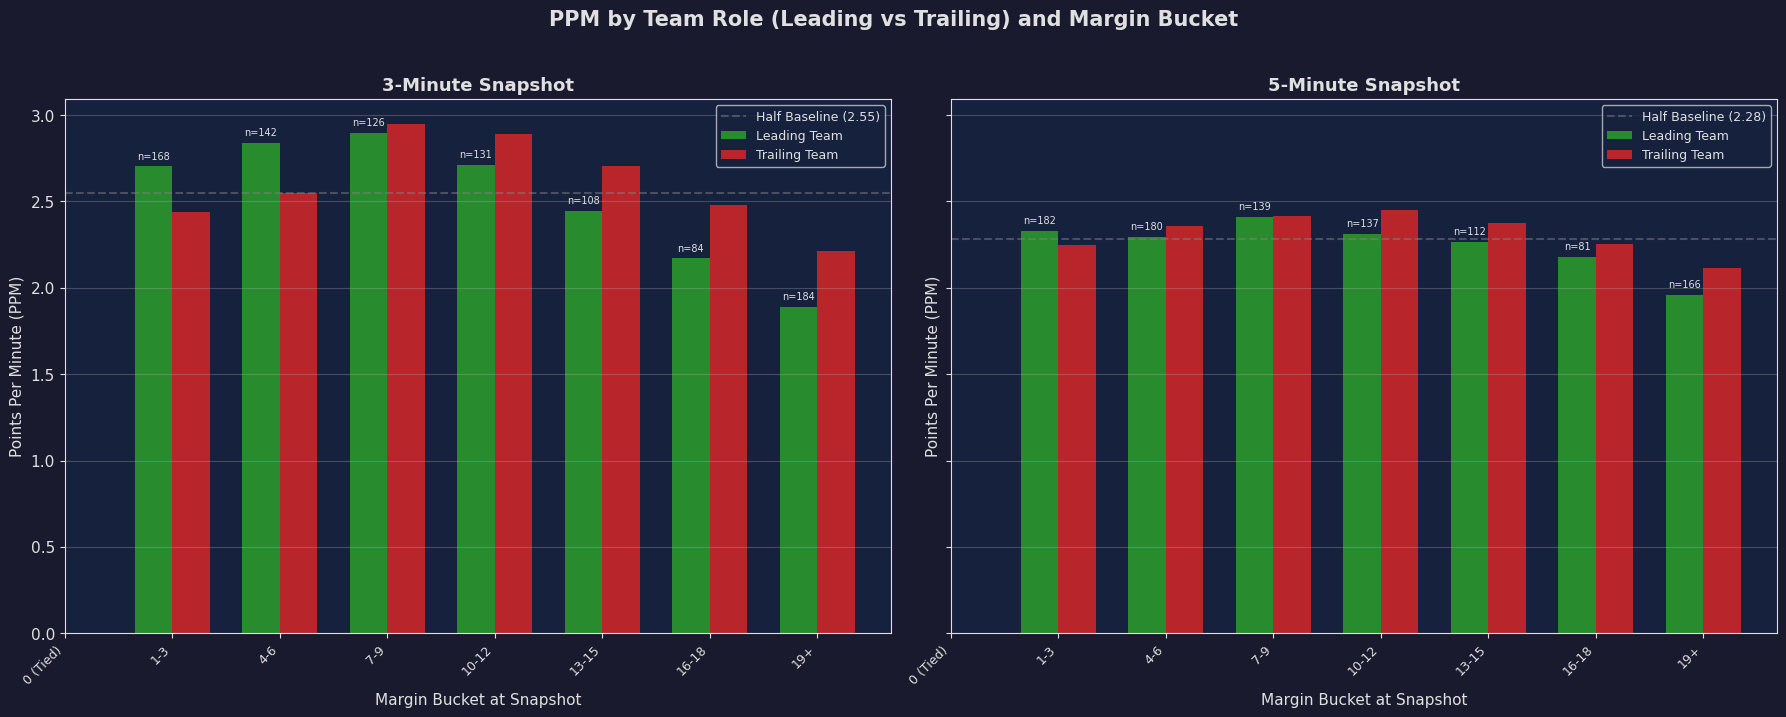

Saved: data/viz_role_ppm_by_bucket.png


In [48]:
# ── Visualization: Leading vs Trailing PPM by Margin Bucket ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, pivot, snapshot_label, baseline_ppm in [
    (axes[0], pivot_role_3, '3-Minute', baseline_3_ppm),
    (axes[1], pivot_role_5, '5-Minute', baseline_5_ppm),
]:
    x = np.arange(len(FINE_LABELS))
    width = 0.35
    
    lead_vals = pivot['Leading'].values
    trail_vals = pivot['Trailing'].values
    games_vals = pivot['Games'].values
    
    bars_lead = ax.bar(x - width/2, lead_vals, width,
                       label='Leading Team', color='#2ca02c', alpha=0.85)
    bars_trail = ax.bar(x + width/2, trail_vals, width,
                        label='Trailing Team', color='#d62728', alpha=0.85)
    
    ax.axhline(baseline_ppm / 2, color='gray', linestyle='--', alpha=0.5,
               label=f'Half Baseline ({baseline_ppm/2:.2f})')
    
    ax.set_xlabel('Margin Bucket at Snapshot', fontsize=11)
    ax.set_ylabel('Points Per Minute (PPM)', fontsize=11)
    ax.set_title(f'{snapshot_label} Snapshot', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(FINE_LABELS, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate game counts
    for bar, n_g in zip(bars_lead, games_vals):
        if n_g > 0 and not np.isnan(bar.get_height()):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.03,
                    f'n={int(n_g)}', ha='center', va='bottom', fontsize=7)

fig.suptitle('PPM by Team Role (Leading vs Trailing) and Margin Bucket',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/viz_role_ppm_by_bucket.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/viz_role_ppm_by_bucket.png')

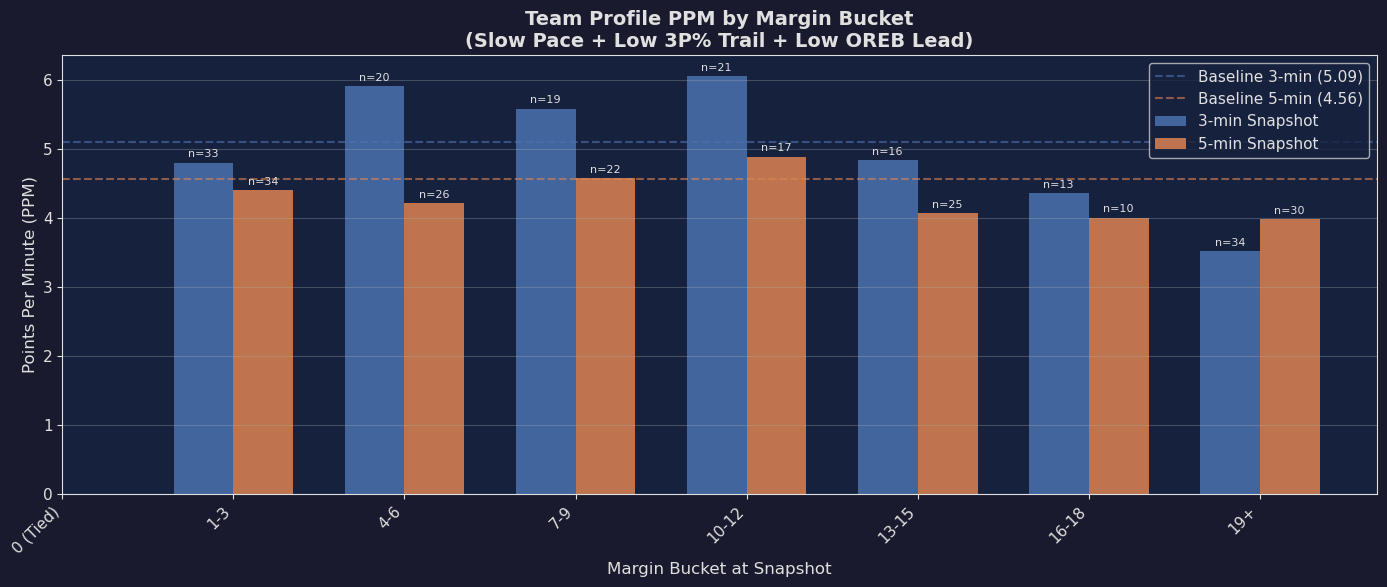

Saved: data/viz_team_profile_ppm.png


In [49]:
# ── Grouped Bar Chart: Profile PPM at 3-min vs 5-min ──
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(FINE_LABELS))
width = 0.35

bars_3 = ax.bar(x - width/2, ppm_3['PPM'].values, width,
                label='3-min Snapshot', color='#4C72B0', alpha=0.85)
bars_5 = ax.bar(x + width/2, ppm_5['PPM'].values, width,
                label='5-min Snapshot', color='#DD8452', alpha=0.85)

ax.axhline(baseline_3_ppm, color='#4C72B0', linestyle='--', alpha=0.6,
           label=f'Baseline 3-min ({baseline_3_ppm:.2f})')
ax.axhline(baseline_5_ppm, color='#DD8452', linestyle='--', alpha=0.6,
           label=f'Baseline 5-min ({baseline_5_ppm:.2f})')

ax.set_xlabel('Margin Bucket at Snapshot', fontsize=12)
ax.set_ylabel('Points Per Minute (PPM)', fontsize=12)
ax.set_title('Team Profile PPM by Margin Bucket\n'
             '(Slow Pace + Low 3P% Trail + Low OREB Lead)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(FINE_LABELS, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Annotate game counts above each bar
for bar, games in zip(bars_3, ppm_3['Games'].values):
    if games > 0 and not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'n={games}', ha='center', va='bottom', fontsize=8)
for bar, games in zip(bars_5, ppm_5['Games'].values):
    if games > 0 and not np.isnan(bar.get_height()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'n={games}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('data/viz_team_profile_ppm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/viz_team_profile_ppm.png')

---
## 9 — Summary

In [50]:
print('='*60)
print(f'  DRIVER ANALYSIS — {SEASON} Season')
print('='*60)
print(f'\n  P6 games (non-tied at 3:00): {len(entry_3_lt):,}')
print(f'  Drivers analyzed: 5')
print(f'    1. Leading team OREB')
print(f'    2. Trailing team 3PA volume')
print(f'    3. Trailing team 3P% efficiency')
print(f'    4. Leading team pace (sec/poss)')
print(f'    5. Trailing team pace')
print(f'\n  Outputs:')
print(f'    PPM by driver quartile tables')
print(f'    Driver x margin bucket interactions')
print(f'    Combined driver profiles')
print(f'    3 visualizations saved to data/')

  DRIVER ANALYSIS — 2024 Season

  P6 games (non-tied at 3:00): 943
  Drivers analyzed: 5
    1. Leading team OREB
    2. Trailing team 3PA volume
    3. Trailing team 3P% efficiency
    4. Leading team pace (sec/poss)
    5. Trailing team pace

  Outputs:
    PPM by driver quartile tables
    Driver x margin bucket interactions
    Combined driver profiles
    3 visualizations saved to data/
